# Stage-Wise Classification of miRNA Signatures (Normal vs. Stage I–IV)

### Classifiers
- **Random Forest (RF)**
- **Logistic Regression (LR)**
- **K-Nearest Neighbors (KNN)**
- **Support Vector Machine with linear kernel (SVM-linear)**

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
DATA_CSV = "breast_cancer.csv"
LABEL_COL = "Label"
CV_THRESHOLD = 50
N_SPLITS = 5

stages = [("Stage I", 1, "Stage_I"),
          ("Stage II", 2, "Stage_II"),
          ("Stage III", 3, "Stage_III"),
          ("Stage IV", 4, "Stage_IV")]

CONSENSUS_RULES = ["intersection", "majority"]
k_values = [5, 10, 15]

consensus_root = Path("stagewise_consensus")
out_dir = Path("stagewise_classification")
out_dir.mkdir(exist_ok=True)

In [3]:
def load_list(fp: Path) -> list[str]:
    s = pd.read_csv(fp, header=0).iloc[:, 0].astype(str)
    return s.str.strip().str.lower().dropna().drop_duplicates().tolist()

def map_features(df_cols: pd.Index, wanted_lower: list[str]) -> list[str]:
    lower_to_orig = {c.lower(): c for c in df_cols}
    return [lower_to_orig[x] for x in wanted_lower if x in lower_to_orig]

def proba_or_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s = (s - s.min()) / (s.max() - s.min() + 1e-12)
        return s
    return model.predict(X)

def make_classifiers():
    return {
        "RF": RandomForestClassifier(
            n_estimators=100, class_weight="balanced_subsample",
            random_state=42, n_jobs=-1, max_depth=10
        ),
        "SVM-linear": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42))
        ]),
        "LR": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
    }

def compute_tpr_tnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return sens, spec

def record_status(results, stage_name, family, k_label, rule, clf_names, status, source):
    for clf_name in clf_names:
        results.append({
            "Stage": stage_name, "Family": family, "k": k_label, "Consensus": rule,
            "n_feats": 0, "missing": np.nan, "Classifier": clf_name,
            "Accuracy": np.nan, "Sensitivity": np.nan, "Specificity": np.nan, "AUC": np.nan,
            "SourceFile": str(source), "Status": status
        })

In [4]:
df = pd.read_csv(DATA_CSV)
assert LABEL_COL in df.columns, f"Column '{LABEL_COL}' not found in {DATA_CSV}"

results = []
clf_defs = make_classifiers()
all_clf_names = list(clf_defs.keys())

print("="*42)
print("DATA DISTRIBUTION AND VALIDATION STRATEGY")
print("="*42)

for stage_name, stage_code, stage_slug in stages:
    df_temp = df[df[LABEL_COL].isin([0, stage_code])]
    counts = df_temp[LABEL_COL].value_counts().to_dict()
    minority = min(counts.values())
    
    method = f"{N_SPLITS}-Fold CV" if minority < CV_THRESHOLD else "Train-Test Split (70/30)"
    warning = " (High uncertainty)" if minority < 20 else ""
    print(f"{stage_name:10s}: Normal={counts.get(0, 0):3d}, Cancer={counts.get(stage_code, 0):3d} → {method}{warning}")

for stage_name, stage_code, stage_slug in stages:
    df_stage = df[df[LABEL_COL].isin([0, stage_code])].copy()
    X_full = df_stage.drop(columns=[LABEL_COL])
    y_full = df_stage[LABEL_COL].replace({0:0, stage_code:1}).astype(int)

    counts = y_full.value_counts().to_dict()
    minority = min(counts.values())
    use_cv = minority < CV_THRESHOLD
    
    if minority < 20:
        print(f"WARNING   : {stage_name} has only {minority} minority samples - results have high uncertainty")
    
    if use_cv:
        n_splits = min(N_SPLITS, minority)
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    else:        
        test_size = 0.30
        strat = y_full if all(v >= 2 for v in counts.values()) else None
        idx = np.arange(len(y_full))
        tr_idx, te_idx = train_test_split(idx, test_size=test_size, stratify=strat, random_state=42)
        Xtr_full, Xte_full = X_full.iloc[tr_idx], X_full.iloc[te_idx]
        ytr, yte = y_full.iloc[tr_idx], y_full.iloc[te_idx]

    def eval_one(feature_list, family, k_label, rule, src):
        n_req = len(feature_list)
        if n_req == 0:
            record_status(results, stage_name, family, k_label, rule, all_clf_names, "empty_list", src)
            return
        
        used_cols = map_features(X_full.columns, feature_list)
        n_used = len(used_cols)
        missing = n_req - n_used
        
        if n_used == 0:
            record_status(results, stage_name, family, k_label, rule, all_clf_names, "no_overlap", src)
            return

        if use_cv:
            X_features = X_full[used_cols].values
            y_data = y_full.values
            
            for clf_name, clf in clf_defs.items():
                y_preds = []
                y_scores = []
                y_trues = []
                
                for train_idx, test_idx in cv.split(X_features, y_data):
                    Xtr, Xte = X_features[train_idx], X_features[test_idx]
                    ytr_cv, yte_cv = y_data[train_idx], y_data[test_idx]
                    
                    model = clone(clf)
                    model.fit(Xtr, ytr_cv)
                    y_pred = model.predict(Xte)
                    y_preds.extend(y_pred)
                    y_trues.extend(yte_cv)
                    
                    try:
                        y_score = proba_or_score(model, Xte)
                        y_scores.extend(y_score)
                    except:
                        y_scores.extend(y_pred)
                
                y_preds = np.array(y_preds)
                y_trues = np.array(y_trues)
                y_scores = np.array(y_scores)
                
                acc = accuracy_score(y_trues, y_preds)
                sens, spec = compute_tpr_tnr(y_trues, y_preds)
                
                try:
                    auc = roc_auc_score(y_trues, y_scores)
                except:
                    auc = np.nan
                
                status = f"ok_cv{n_splits}_low_n" if minority < 20 else f"ok_cv{n_splits}"
                
                results.append({
                    "Stage": stage_name, "Family": family, "k": k_label, "Consensus": rule,
                    "n_feats": n_used, "missing": missing, "Classifier": clf_name,
                    "Accuracy": round(acc, 3),
                    "Sensitivity": round(sens, 3) if pd.notna(sens) else np.nan,
                    "Specificity": round(spec, 3) if pd.notna(spec) else np.nan,
                    "AUC": round(auc, 3) if pd.notna(auc) else np.nan,
                    "SourceFile": str(src), "Status": status
                })
        else:
            Xtr, Xte = Xtr_full[used_cols].values, Xte_full[used_cols].values
            for clf_name, clf in clf_defs.items():
                model = clone(clf)
                model.fit(Xtr, ytr)
                y_pred = model.predict(Xte)
                acc = accuracy_score(yte, y_pred)
                sens, spec = compute_tpr_tnr(yte, y_pred)
                
                try:
                    y_score = proba_or_score(model, Xte)
                    auc = roc_auc_score(yte, y_score)
                except:
                    auc = np.nan
                
                results.append({
                    "Stage": stage_name, "Family": family, "k": k_label, "Consensus": rule,
                    "n_feats": n_used, "missing": missing, "Classifier": clf_name,
                    "Accuracy": round(acc, 3),
                    "Sensitivity": round(sens, 3) if pd.notna(sens) else np.nan,
                    "Specificity": round(spec, 3) if pd.notna(spec) else np.nan,
                    "AUC": round(auc, 3) if pd.notna(auc) else np.nan,
                    "SourceFile": str(src), "Status": "ok"
                })

    for family in ["Traditional", "DeepLearning"]:
        for k in k_values:
            for rule in CONSENSUS_RULES:
                fp = consensus_root / f"Consensus_{family}_top{k}_{stage_slug}_{rule}.csv"
                if fp.exists():
                    eval_one(load_list(fp), family, f"top{k}", rule, fp)
                else:
                    record_status(results, stage_name, family, f"top{k}", rule, all_clf_names, "file_missing", fp)

    family = "Clustering"
    for rule in CONSENSUS_RULES:
        fp = consensus_root / f"Consensus_Clustering_{stage_slug}_{rule}.csv"
        if fp.exists():
            eval_one(load_list(fp), family, "", rule, fp)
        else:
            record_status(results, stage_name, family, "", rule, all_clf_names, "file_missing", fp)

DATA DISTRIBUTION AND VALIDATION STRATEGY
Stage I   : Normal=265, Cancer=173 → Train-Test Split (70/30)
Stage II  : Normal=265, Cancer=595 → Train-Test Split (70/30)
Stage III : Normal=265, Cancer=161 → Train-Test Split (70/30)
Stage IV  : Normal=265, Cancer= 15 → 5-Fold CV (High uncertainty)


In [5]:
res_df = pd.DataFrame(results, columns=[
    "Stage","Family","k","Consensus","Classifier",
    "n_feats","missing","Accuracy","Sensitivity","Specificity","AUC",
    "SourceFile","Status"
])
res_df.sort_values(["Stage","Classifier","Family","k","Consensus"], inplace=True)

out_path = out_dir / "Consensus_Classification_Results.csv"
res_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.as_posix()}")

for stage in res_df["Stage"].unique():
    print("\n" + "="*80)
    print(stage)
    print("="*80)
    
    dfp = res_df[(res_df["Stage"] == stage) & (res_df["Status"].str.startswith("ok"))].copy()
    
    if dfp.empty:
        print("No consensus lists available.")
        continue
    
    if dfp["Status"].str.contains("cv").any():
        print("(Using Stratified K-Fold Cross-Validation)")
    if dfp["Status"].str.contains("low_n").any():
        print("WARNING: Small sample size - results have high uncertainty")
    print()
    
    dfp["Method"] = dfp.apply(lambda r: f"{r['Family']}{('-' + r['k']) if r['k'] else ''}-{r['Consensus']}", axis=1)
    dfp = dfp[["Classifier","Method","Accuracy","Sensitivity","Specificity","AUC"]]
    dfp = dfp.sort_values(["Classifier","Method"])
    print(dfp.to_string(index=False))

Saved: stagewise_classification/Consensus_Classification_Results.csv

Stage I

Classifier                      Method  Accuracy  Sensitivity  Specificity   AUC
       KNN         Clustering-majority     0.470        0.615        0.375 0.495
       KNN DeepLearning-top10-majority     0.583        0.038        0.938 0.475
       KNN DeepLearning-top15-majority     0.523        0.154        0.762 0.449
       KNN  Traditional-top10-majority     0.530        0.327        0.662 0.465
       KNN  Traditional-top15-majority     0.523        0.288        0.675 0.481
       KNN   Traditional-top5-majority     0.523        0.346        0.638 0.518
        LR         Clustering-majority     0.598        0.423        0.712 0.569
        LR DeepLearning-top10-majority     0.424        0.808        0.175 0.490
        LR DeepLearning-top15-majority     0.492        0.615        0.412 0.472
        LR  Traditional-top10-majority     0.538        0.538        0.538 0.539
        LR  Traditional-top15-

## Stage-Specific Classification Results

Stage I: Highest accuracy
  → 61.4% (Traditional-top5, SVM-linear)
     Sens=40.4%, Spec=75.0%

Stage II: Highest accuracy
  → 64.0% (Traditional-top5, SVM-linear)
     Sens=86.0%, Spec=15.0%

Stage III: Highest accuracy
  → 61.7% (Clustering-nan, RF)
     Sens=8.3%, Spec=93.8%

Stage IV: Traditional-top5 with highest sensitivity
  → 84.6% (Traditional-top5, LR)
     Sens=60.0%, Spec=86.0%



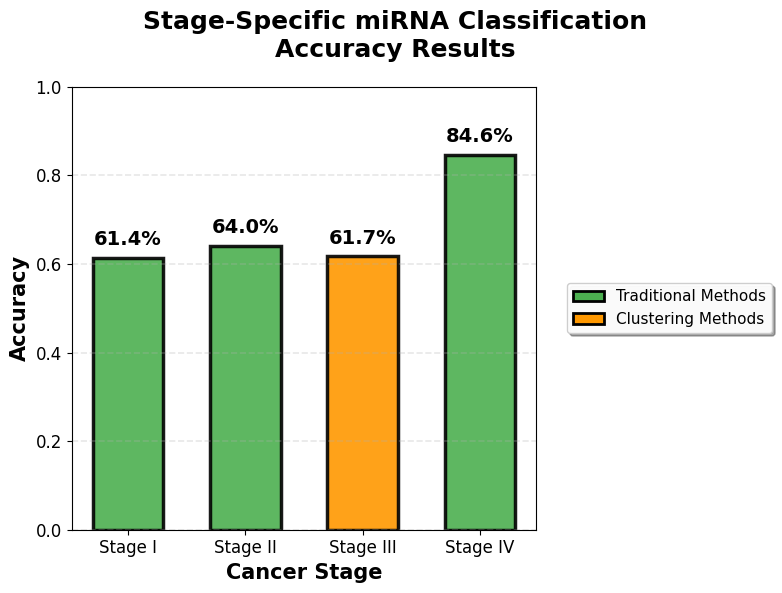

In [6]:
out_dir = Path("stagewise_classification")
res_df = pd.read_csv(out_dir / "Consensus_Classification_Results.csv")

MIN_SPEC = 0.15
MIN_SENS_BALANCED = 0.40

# Filter to majority consensus with minimum specificity
successful = res_df[
    (res_df["Status"].str.startswith("ok")) &
    (res_df["Consensus"] == "majority") &
    (res_df["Specificity"] >= MIN_SPEC)
].copy()

presentation_results = []
for stage in ["Stage I", "Stage II", "Stage III", "Stage IV"]:
    stage_data = successful[successful["Stage"] == stage]
    
    if stage == "Stage IV":
        # Stage IV: Prefer highest sensitivity among Traditional-top5 balanced results
        trad_top5_balanced = stage_data[
            (stage_data["Family"] == "Traditional") &
            (stage_data["k"] == "top5") &
            (stage_data["Sensitivity"] >= MIN_SENS_BALANCED)
        ]
        
        if len(trad_top5_balanced) > 0:
            best = trad_top5_balanced.loc[trad_top5_balanced["Sensitivity"].idxmax()]
            print(f"{stage}: Traditional-top5 with highest sensitivity")
        else:
            best = stage_data.loc[stage_data["Accuracy"].idxmax()]
            print(f"{stage}: Highest accuracy")
    else:
        # Stages I-III: Highest accuracy
        best = stage_data.loc[stage_data["Accuracy"].idxmax()]
        print(f"{stage}: Highest accuracy")
    
    print(f"  → {best['Accuracy']:.1%} ({best['Family']}-{best['k']}, {best['Classifier']})")
    print(f"     Sens={best['Sensitivity']:.1%}, Spec={best['Specificity']:.1%}\n")
    
    presentation_results.append(best)

pres_df = pd.DataFrame(presentation_results)

family_colors = {
    'Traditional': '#4CAF50',
    'DeepLearning': '#2196F3',
    'Clustering': '#FF9800'
}
colors = [family_colors[f] for f in pres_df['Family']]

# Accuracy by stage
fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))
fig1.suptitle('Stage-Specific miRNA Classification\nAccuracy Results', 
              fontsize=18, fontweight='bold', y=0.98)

x_pos = np.arange(len(pres_df))
bars = ax1.bar(x_pos, pres_df['Accuracy'], color=colors, 
               edgecolor='black', linewidth=2.5, alpha=0.9, width=0.6)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', 
             fontsize=14, fontweight='bold')

ax1.set_ylabel('Accuracy', fontsize=15, fontweight='bold')
ax1.set_xlabel('Cancer Stage', fontsize=15, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(pres_df['Stage'], fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.2)
ax1.tick_params(axis='both', labelsize=12)

legend_elements = [
    Patch(facecolor='#4CAF50', edgecolor='black', label='Traditional Methods', linewidth=2),
    Patch(facecolor='#FF9800', edgecolor='black', label='Clustering Methods', linewidth=2)
]
ax1.legend(handles=legend_elements, fontsize=11, framealpha=0.95, 
          loc='center left', bbox_to_anchor=(1.05, 0.5), fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig(out_dir / "Graph1_Accuracy_by_Stage.png", dpi=300, bbox_inches='tight')
plt.show()

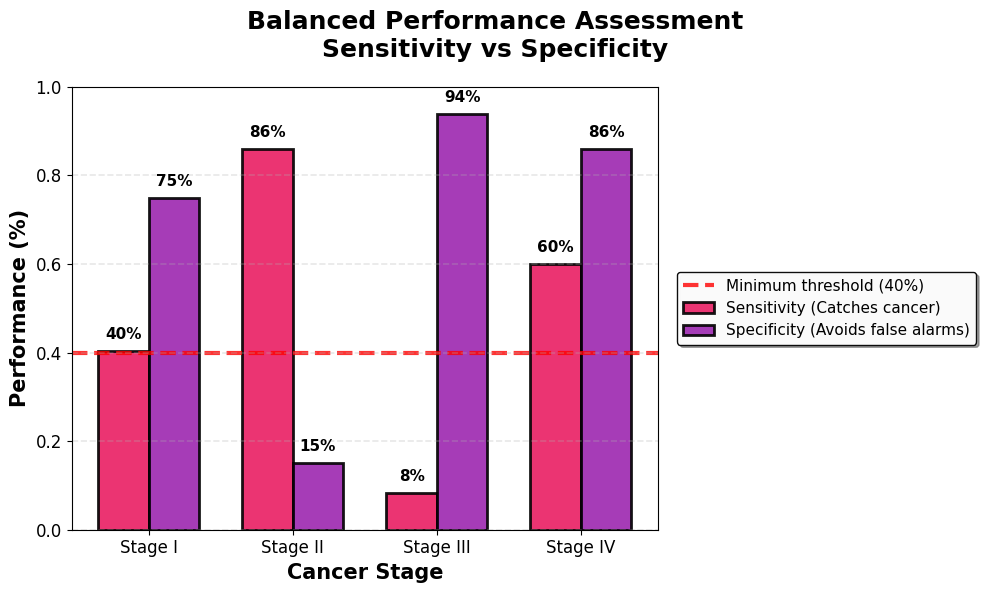

In [7]:
# Sensitivity vs specificity
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))
fig2.suptitle('Balanced Performance Assessment\nSensitivity vs Specificity', 
              fontsize=18, fontweight='bold', y=0.98)

width = 0.35
x2_pos = np.arange(len(pres_df))

bars_sens = ax2.bar(x2_pos - width/2, pres_df['Sensitivity'], width,
                    label='Sensitivity (Catches cancer)', 
                    color='#E91E63', edgecolor='black', linewidth=2, alpha=0.9)
bars_spec = ax2.bar(x2_pos + width/2, pres_df['Specificity'], width,
                    label='Specificity (Avoids false alarms)', 
                    color='#9C27B0', edgecolor='black', linewidth=2, alpha=0.9)

for bars in [bars_sens, bars_spec]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.0%}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

ax2.set_ylabel('Performance (%)', fontsize=15, fontweight='bold')
ax2.set_xlabel('Cancer Stage', fontsize=15, fontweight='bold')
ax2.set_xticks(x2_pos)
ax2.set_xticklabels(pres_df['Stage'], fontsize=13)
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.2)
ax2.tick_params(axis='both', labelsize=12)

# 40% balanced performance threshold line
ax2.axhline(y=0.40, color='red', linestyle='--', linewidth=3, alpha=0.8, 
            label='Minimum threshold (40%)', zorder=1)

ax2.legend(fontsize=11, framealpha=0.95, edgecolor='black',
          loc='center left', bbox_to_anchor=(1.02, 0.5), fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig(out_dir / "Graph2_Sensitivity_vs_Specificity.png", dpi=300, bbox_inches='tight')
plt.show()